<a href="https://colab.research.google.com/github/new2datasci/Deep-learning-architectures/blob/main/Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Warning :
# Do "File -> Save a copy in Drive" before you start modifying the notebook, otherwise your modifications will not be saved.


In [ ]:
import argparse
import os
import time

import PIL
from PIL import Image

import numpy as np
import torchvision
import pickle

import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.utils.data
import torchvision.datasets as datasets
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.autograd import Variable
import torchvision
vgg16 = torchvision.models.vgg16(pretrained=True)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report,
)

from sklearn.svm import LinearSVC
from torch.autograd import Variable
from tqdm import tqdm

# Partie 1 : Architecture VGG16 : Apply the network on several images

In [ ]:
#!wget https://github.com/cdancette/deep-learning-polytech-tp6-7/raw/master/tp8/imagenet_classes.pkl
!wget https://github.com/rdfia/rdfia.github.io/raw/master/data/3-a/imagenet_classes.pkl

# Bonus : Classifiez des exemples avec vgg16 et commentez le résultat dans votre rapport.
!wget --content-disposition https://unsplash.com/photos/gKXKBY-C-Dk/download?force=true -O cat.jpg
!wget --content-disposition https://unsplash.com/photos/qO-PIF84Vxg/download?force=true -O dog.jpg

--2026-01-11 12:41:04--  https://github.com/rdfia/rdfia.github.io/raw/master/data/3-a/imagenet_classes.pkl
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rdfia/rdfia.github.io/master/data/3-a/imagenet_classes.pkl [following]
--2026-01-11 12:41:05--  https://raw.githubusercontent.com/rdfia/rdfia.github.io/master/data/3-a/imagenet_classes.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 35454 (35K) [text/plain]
Saving to: ‘imagenet_classes.pkl’

imagenet_classes.pk 100%[===================>]  34.62K  --.-KB/s    in 0s      

2026-01-11 12:41:05 (226 MB/s) - ‘imagenet_classes.pkl’ saved [35

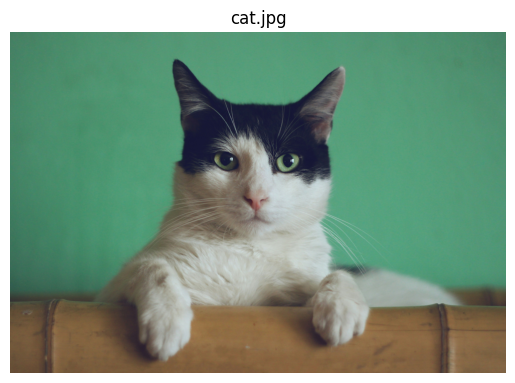

Egyptian cat 0.27886947989463806
carton 0.18154224753379822
lynx, catamount 0.13544031977653503
tabby, tabby cat 0.09797056019306183
tiger cat 0.04034162312746048


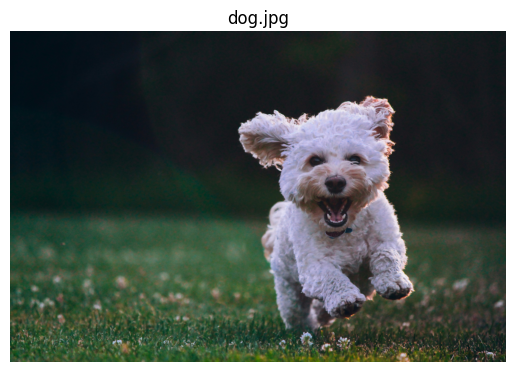

wire-haired fox terrier 0.2329525351524353
Lakeland terrier 0.19323866069316864
miniature poodle 0.13325706124305725
miniature schnauzer 0.09209678322076797
Bedlington terrier 0.05918493494391441


FileNotFoundError: [Errno 2] No such file or directory: 'car.jpg'

In [ ]:

# Load ImageNet labels
imagenet_classes = pickle.load(open('imagenet_classes.pkl', 'rb'))

# ImageNet mean / std
mu = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
sigma = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# Load pretrained VGG16
vgg16 = torchvision.models.vgg16(pretrained=True)
vgg16.eval()   # IMPORTANT

# List of images to test
image_names = [
    "cat.jpg",
    "dog.jpg",
    "car.jpg"

]

for name in image_names:

    # Load and display image
    img_pil = Image.open(name).convert("RGB")
    plt.imshow(img_pil)
    plt.title(name)
    plt.axis("off")
    plt.show()

    # Preprocessing
    img = img_pil.resize((224, 224), Image.BILINEAR)
    img = np.array(img, dtype=np.float32) / 255.0
    img = img.transpose((2, 0, 1))              # (3, 224, 224)
    x = torch.from_numpy(img)

    # ImageNet normalization
    x = (x - mu) / sigma

    # Add batch dimension
    x = x.unsqueeze(0)                           # (1, 3, 224, 224)

    # Forward pass
    with torch.no_grad():
        y = vgg16(x)

    # Softmax + top-1 prediction
    probs = torch.softmax(y, dim=1)
    top5_prob, top5_idx = probs.topk(5)
    for i in range(5):
        print(imagenet_classes[top5_idx[0, i].item()],
          top5_prob[0, i].item())

    #top_prob, top_idx = probs.max(dim=1)

        #print(f"Image: {name}")
        #print("Predicted class:", imagenet_classes[top5_idx.item()])
        #print("Probability:", top5_prob.item())
        #print("-" * 40)


# Imagenet Normalization

In [ ]:
topk = 5
results = {}

for name in image_names:

    img_pil = Image.open(name).convert("RGB")

    # Preprocess
    img = img_pil.resize((224, 224), Image.BILINEAR)
    img = np.array(img, dtype=np.float32) / 255.0
    img = img.transpose((2, 0, 1))
    x = torch.from_numpy(img)
    x = (x - mu) / sigma
    x = x.unsqueeze(0)

    with torch.no_grad():
        y = vgg16(x)

    probs = torch.softmax(y, dim=1)

    topk_prob, topk_idx = probs.topk(topk)

    results[name] = {
        "labels": [imagenet_classes[i.item()] for i in topk_idx[0]],
        "probs": topk_prob[0].cpu().numpy()
    }


In [ ]:
def plot_topk_bar(image_name, results):
    labels = results[image_name]["labels"]
    probs = results[image_name]["probs"] * 100  # %

    # Highlight the max probability
    max_idx = np.argmax(probs)
    colors = ["tab:blue"] * len(probs)
    colors[max_idx] = "tab:orange"

    plt.figure(figsize=(6, 5))
    bars = plt.bar(labels, probs, color=colors)

    plt.title(f"Top 5 predictions for {image_name.split('.')[0]}")
    plt.ylabel("Probability (%)")
    plt.xticks(rotation=30, ha="right")

    for bar, p in zip(bars, probs):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{p:.2f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()


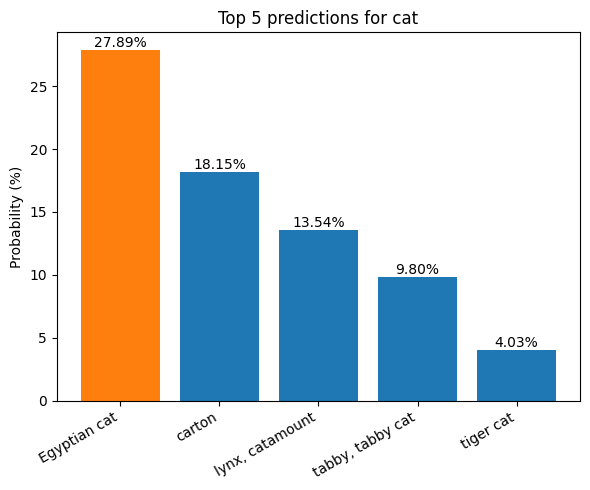

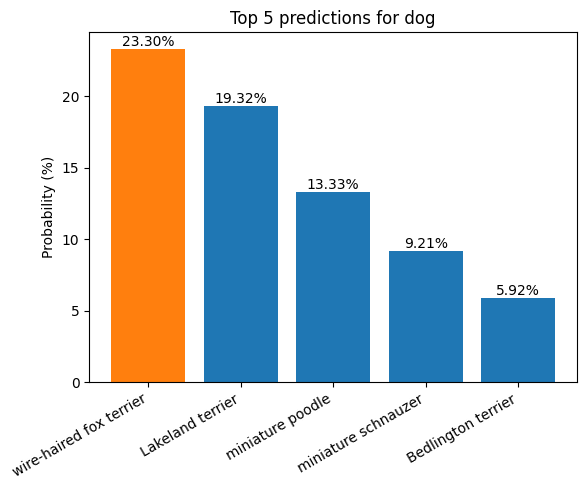

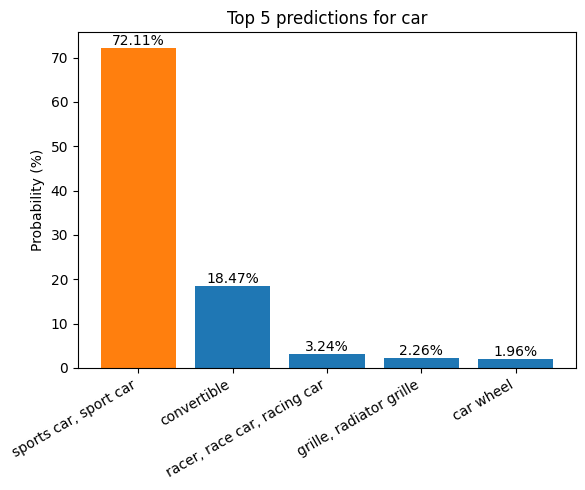

In [ ]:
plot_topk_bar("cat.jpg", results)
plot_topk_bar("dog.jpg", results)
plot_topk_bar("car.jpg", results)

# Activation Maps

In [ ]:
def show_colored_activations(activations, nrows=8, ncols=8, cmap="viridis"):
    """
    activations: tensor of shape (64, H, W)
    """
    plt.figure(figsize=(12, 12))

    for i in range(nrows * ncols):
        ax = plt.subplot(nrows, ncols, i + 1)

        act = activations[i].cpu().numpy()
        act = act - act.min()
        act = act / (act.max() + 1e-6)

        ax.imshow(act, cmap=cmap)
        ax.axis("off")

    plt.suptitle("Activation maps after first convolutional layer", fontsize=16)
    plt.tight_layout()
    plt.show()


In [ ]:
def preprocess_image(name):
    img_pil = Image.open(name).convert("RGB")

    img = img_pil.resize((224, 224), Image.BILINEAR)
    img = np.array(img, dtype=np.float32) / 255.0
    img = img.transpose((2, 0, 1))  # (3, 224, 224)
    x = torch.from_numpy(img)

    # ImageNet normalization
    mu = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    sigma = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    x = (x - mu) / sigma

    return x.unsqueeze(0)  # (1, 3, 224, 224)


Processing cat.jpg


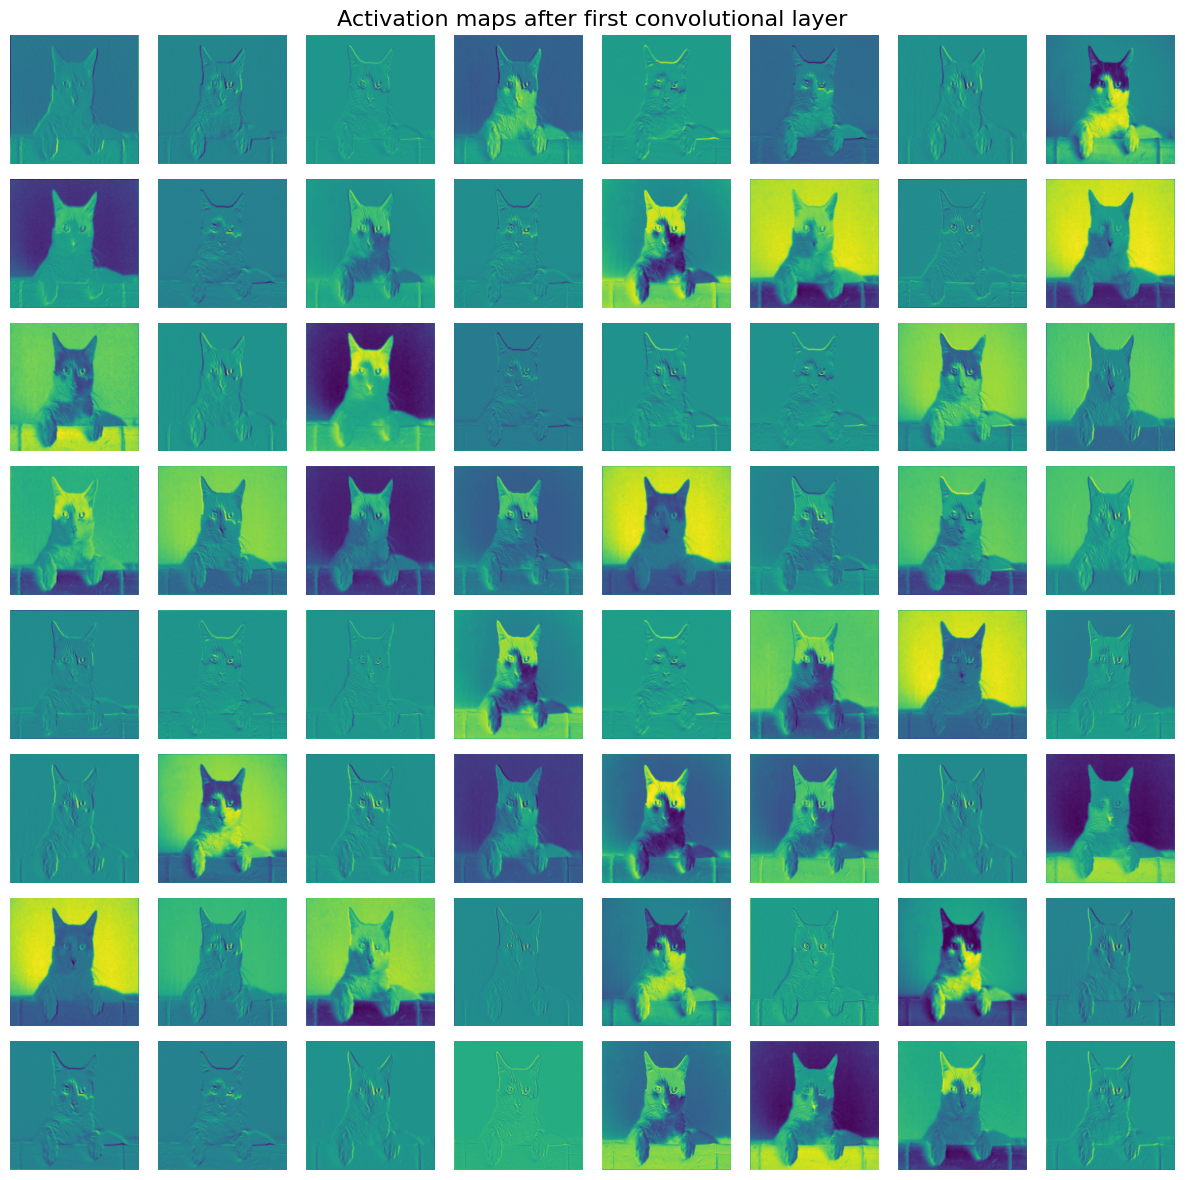

Processing dog.jpg


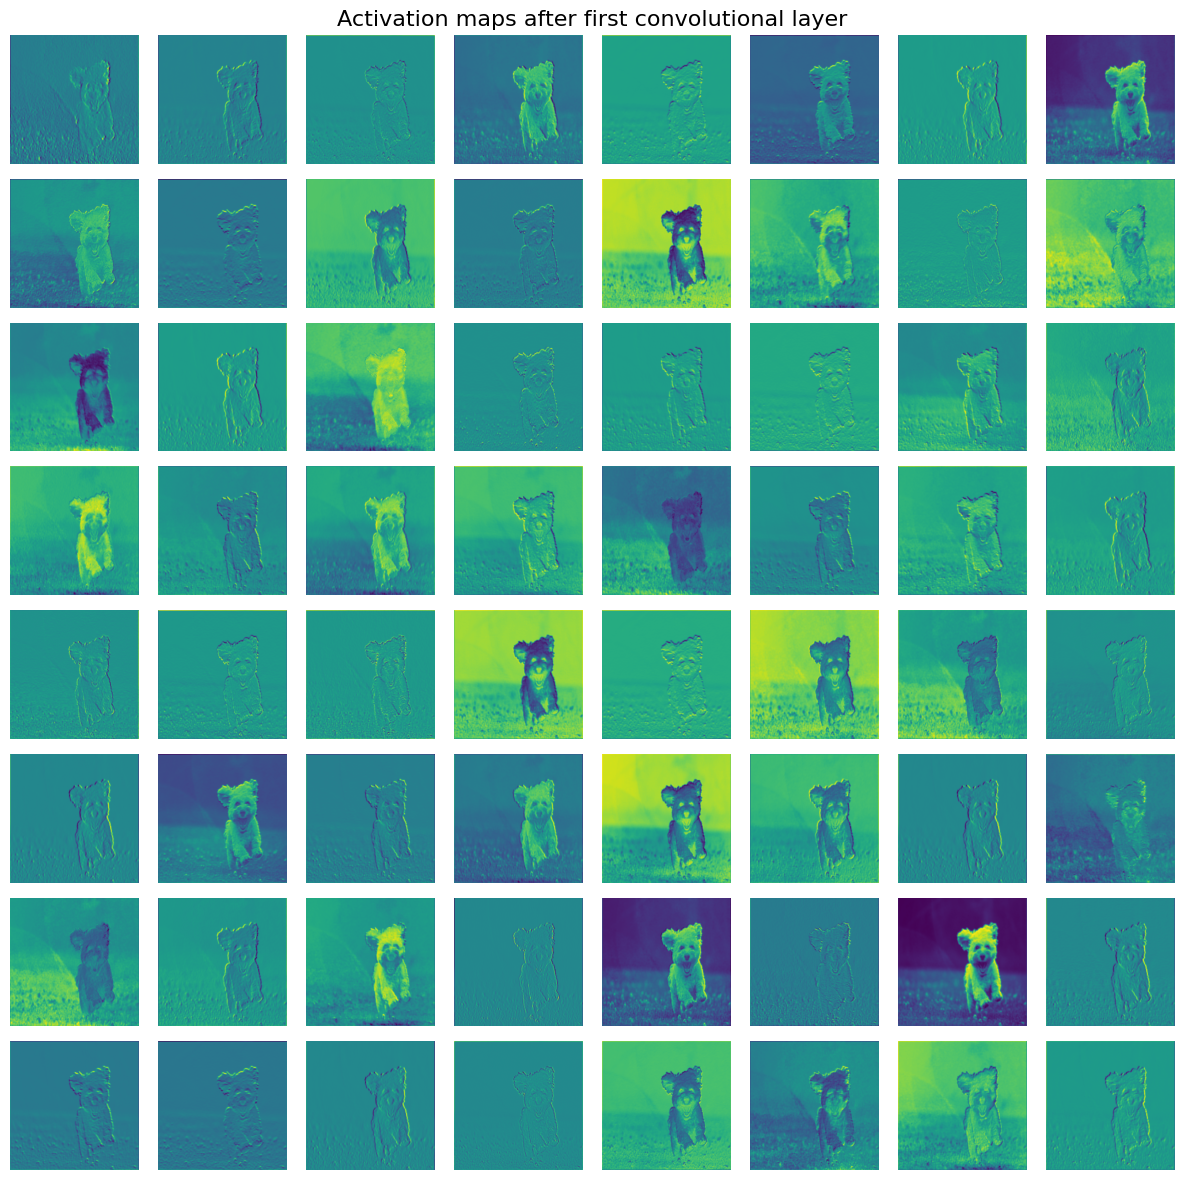

Processing car.jpg


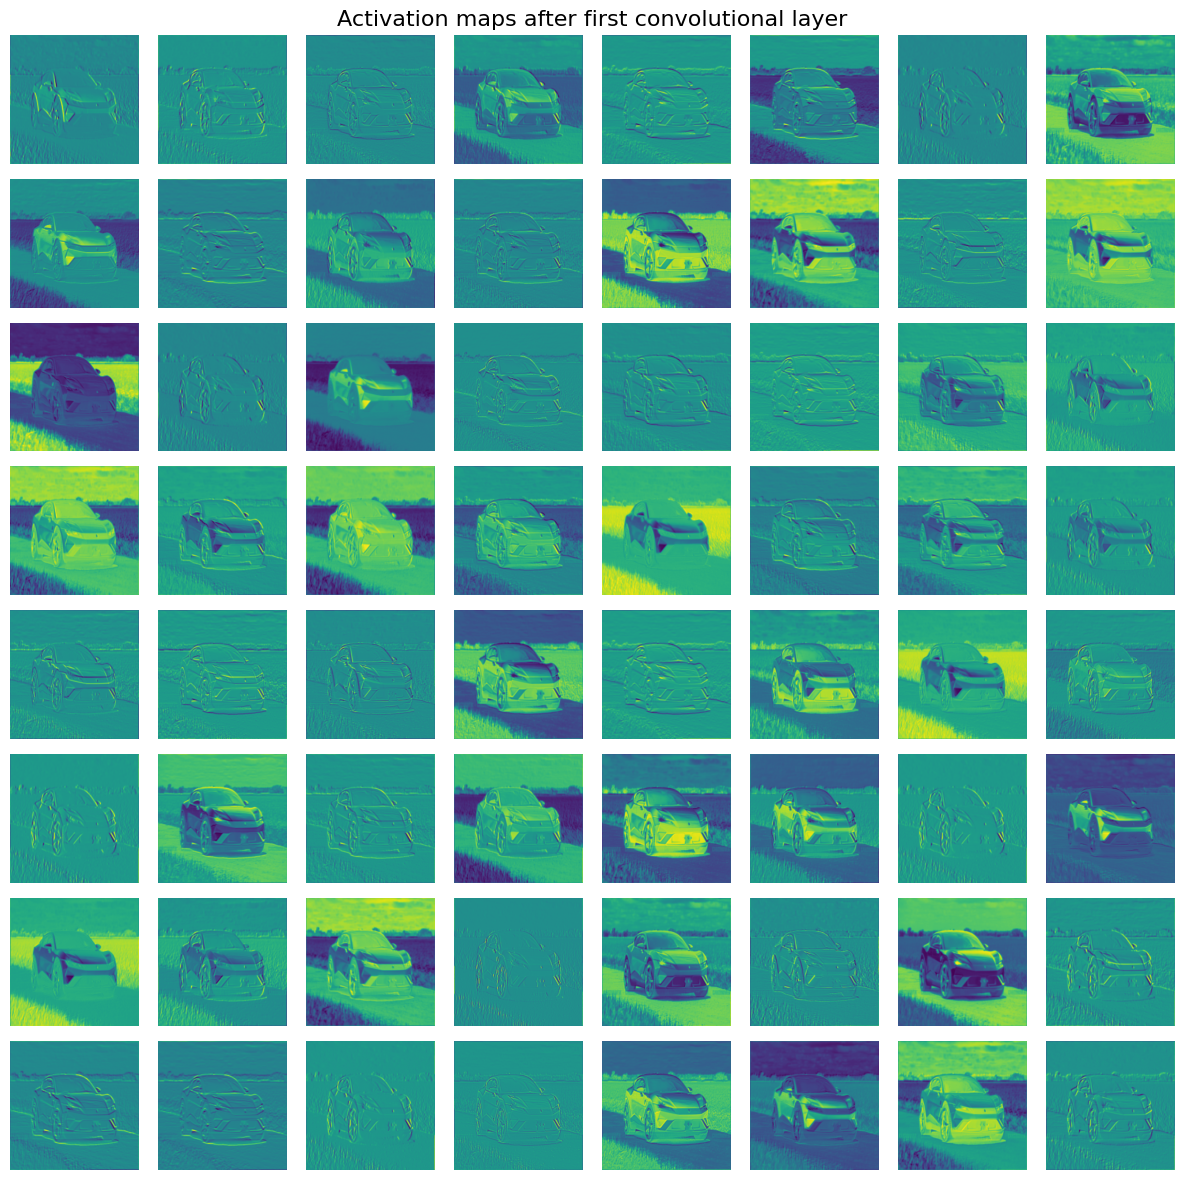

In [ ]:
image_names = ["cat.jpg", "dog.jpg", "car.jpg"]

vgg16.eval()
first_conv = vgg16.features[0]

for name in image_names:
    print(f"Processing {name}")

    x = preprocess_image(name)

    with torch.no_grad():
        activations = first_conv(x).squeeze(0)  # (64, H, W)

    show_colored_activations(
        activations,
        nrows=8,
        ncols=8,
        cmap="viridis"
    )


# Partie 2: Transfer Learning avec VGG16 sur 15 Scene

In [ ]:
#!wget https://github.com/cdancette/deep-learning-polytech-tp6-7/raw/master/tp8/15ScenesData.zip
!wget https://github.com/rdfia/rdfia.github.io/raw/master/data/3-a/15ScenesData.zip

!unzip 15ScenesData.zip

--2026-01-11 12:42:14--  https://github.com/rdfia/rdfia.github.io/raw/master/data/3-a/15ScenesData.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rdfia/rdfia.github.io/master/data/3-a/15ScenesData.zip [following]
--2026-01-11 12:42:14--  https://raw.githubusercontent.com/rdfia/rdfia.github.io/master/data/3-a/15ScenesData.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 86520868 (83M) [application/zip]
Saving to: ‘15ScenesData.zip’

15ScenesData.zip    100%[===================>]  82.51M  --.-KB/s    in 0.1s    

2026-01-11 12:42:20 (612 MB/s) - ‘15ScenesData.zip’ saved [86520868/86520

In [ ]:
ls 15SceneData/test/bedroom/

image_0003.jpg  image_0042.jpg  image_0082.jpg  image_0124.jpg  image_0170.jpg
image_0004.jpg  image_0043.jpg  image_0084.jpg  image_0128.jpg  image_0175.jpg
image_0006.jpg  image_0047.jpg  image_0086.jpg  image_0130.jpg  image_0176.jpg
image_0007.jpg  image_0049.jpg  image_0087.jpg  image_0131.jpg  image_0180.jpg
image_0008.jpg  image_0050.jpg  image_0088.jpg  image_0134.jpg  image_0182.jpg
image_0011.jpg  image_0052.jpg  image_0090.jpg  image_0135.jpg  image_0189.jpg
image_0013.jpg  image_0053.jpg  image_0092.jpg  image_0138.jpg  image_0190.jpg
image_0014.jpg  image_0054.jpg  image_0093.jpg  image_0140.jpg  image_0191.jpg
image_0016.jpg  image_0056.jpg  image_0095.jpg  image_0141.jpg  image_0192.jpg
image_0017.jpg  image_0059.jpg  image_0096.jpg  image_0142.jpg  image_0195.jpg
image_0018.jpg  image_0060.jpg  image_0097.jpg  image_0144.jpg  image_0196.jpg
image_0019.jpg  image_0062.jpg  image_0098.jpg  image_0148.jpg  image_0200.jpg
image_0020.jpg  image_0063.jpg  image_0103.jpg  imag

In [ ]:
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader
from sklearn.preprocessing import normalize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class VGG16Features(nn.Module):
    """
    Returns features from VGG16 at:
      - 'relu6': after classifier[1]
      - 'relu7': after classifier[4]
      - 'fc8'  : final logits (classifier[6])
    """
    def __init__(self, pretrained=True, layer='relu7'):
        super().__init__()
        assert layer in ['relu6', 'relu7', 'fc8']
        self.layer = layer

        vgg = models.vgg16(pretrained=pretrained)
        self.features = vgg.features          # conv blocks
        self.avgpool = vgg.avgpool
        self.classifier = vgg.classifier      # FC layers

    def forward(self, x):
        # Convolutional part
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        # Now walk through classifier until the layer we want
        if self.layer == 'relu6':
            x = self.classifier[0](x)  # fc6
            x = self.classifier[1](x)  # relu6
            return x

        elif self.layer == 'relu7':
            x = self.classifier[0](x)  # fc6
            x = self.classifier[1](x)  # relu6
            x = self.classifier[2](x)  # dropout
            x = self.classifier[3](x)  # fc7
            x = self.classifier[4](x)  # relu7
            return x

        else:  # 'fc8'
            x = self.classifier(x)     # full classifier
            return x


In [ ]:
def make_dataloaders(root_dir, batch_size=16):
    """
    Expects:
        root_dir/train/...
        root_dir/test/...
    """
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],   # ImageNet mean
            std=[0.229, 0.224, 0.225],    # ImageNet std
        ),
    ])

    train_ds = datasets.ImageFolder(os.path.join(root_dir, 'train'), transform=transform)
    test_ds  = datasets.ImageFolder(os.path.join(root_dir, 'test'),  transform=transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=4)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=4)

    return train_loader, test_loader, train_ds.classes


In [ ]:
def extract_features(dataloader, model):
    model.eval()
    feats = []
    labels = []

    if torch.cuda.is_available():
        model = model.cuda()

    with torch.no_grad():
        for imgs, y in dataloader:
            if torch.cuda.is_available():
                imgs = imgs.cuda()

            out = model(imgs)          # (batch_size, feature_dim)
            feats.append(out.cpu().numpy())
            labels.append(y.numpy())

    feats = np.concatenate(feats, axis=0)
    labels = np.concatenate(labels, axis=0)

    return feats, labels


# **Train SVM with C = 1**

In [ ]:
def train_svm_and_eval(X_train, y_train, X_test, y_test, C=1.0):
    clf = LinearSVC(C=C, max_iter=10000)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return acc


In [ ]:
def main(data_root="15SceneData", batch_size=8):
    print("Building dataloaders...")
    train_loader, test_loader, classes = make_dataloaders(data_root, batch_size=batch_size)
    print(f"Found {len(classes)} classes:", classes)

    results = {}

    for layer in ['relu6', 'relu7', 'fc8']:
        print(f"\n=== Extracting features at {layer} ===")
        model = VGG16Features(pretrained=True, layer=layer)

        if torch.cuda.is_available():
            torch.backends.cudnn.benchmark = True

        X_train, y_train = extract_features(train_loader, model)
        X_test,  y_test  = extract_features(test_loader, model)

        print(f"Train features shape for {layer}:", X_train.shape)
        print(f"Test  features shape for {layer}:", X_test.shape)

        print(f"Training LinearSVC(C=1.0) on {layer} features...")
        acc = train_svm_and_eval(X_train, y_train, X_test, y_test, C=1.0)
        results[layer] = acc
        print(f"Accuracy using {layer}: {acc:.4f}")

    print("\n=== Summary ===")
    for layer, acc in results.items():
        print(f"{layer}: {acc:.4f}")


In [ ]:
if __name__ == "__main__":
    main(data_root="15SceneData", batch_size=8)


Building dataloaders...
Found 15 classes: ['bedroom', 'coast', 'forest', 'highway', 'industrial', 'insidecity', 'kitchen', 'livingroom', 'mountain', 'office', 'opencountry', 'store', 'street', 'suburb', 'tallbuilding']

=== Extracting features at relu6 ===


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Train features shape for relu6: (1500, 4096)
Test  features shape for relu6: (2985, 4096)
Training LinearSVC(C=1.0) on relu6 features...
Accuracy using relu6: 0.9015

=== Extracting features at relu7 ===


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker n

Train features shape for relu7: (1500, 4096)
Test  features shape for relu7: (2985, 4096)
Training LinearSVC(C=1.0) on relu7 features...
Accuracy using relu7: 0.8858

=== Extracting features at fc8 ===


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker n

Train features shape for fc8: (1500, 1000)
Test  features shape for fc8: (2985, 1000)
Training LinearSVC(C=1.0) on fc8 features...
Accuracy using fc8: 0.8516

=== Summary ===
relu6: 0.9015
relu7: 0.8858
fc8: 0.8516


In [ ]:
PRINT_INTERVAL = 50
CUDA = True

def get_dataset(batch_size, path):
    """
    Returns DataLoaders for 15-Scene train/test with:
        - grayscale -> RGB (3 channels)
        - resize to 224x224
        - ImageNet normalization
    """
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    # Expand a grayscale image to 3 channels (RGB) by duplication
    def duplicateChannel(img):
        img = img.convert('L')
        np_img = np.array(img, dtype=np.uint8)
        np_img = np.dstack([np_img, np_img, np_img])
        img = Image.fromarray(np_img, 'RGB')
        return img

    def resizeImage(img):
        return img.resize((224, 224), Image.BILINEAR)

    # Pre-processing: duplicate -> resize -> tensor -> normalize
    transform = transforms.Compose([
        transforms.Lambda(duplicateChannel),
        transforms.Lambda(resizeImage),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    train_dataset = datasets.ImageFolder(
        os.path.join(path, "train"),
        transform=transform
    )
    val_dataset = datasets.ImageFolder(
        os.path.join(path, "test"),
        transform=transform
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        pin_memory=CUDA, num_workers=2
    )
    val_loader = torch.utils.data.DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        pin_memory=CUDA, num_workers=2
    )

    return train_loader, val_loader


In [ ]:
def extract_features(data, model):
    # init lists (easier than prealloc without knowing N)
    X_list = []
    y_list = []

    with torch.no_grad():
        for i, (input, target) in enumerate(data):
            if i % PRINT_INTERVAL == 0:
                print('Batch {0:03d}/{1:03d}'.format(i, len(data)))

            if CUDA:
                input = input.cuda(non_blocking=True)

            out = model(input)                  # (B, 4096)
            X_list.append(out.cpu().numpy())
            y_list.append(target.numpy())

    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    return X, y


In [ ]:
import time
def main(path="15SceneData", batch_size=8):
    print('Instanciation de VGG16relu7')
    # Replace with truncated network for feature extraction
    model = VGG16Features(pretrained=True, layer="relu7")


    model.eval()
    if CUDA:
        cudnn.benchmark = True
        model = model.cuda()

    # Load data
    print('Récupération des données')
    train, test = get_dataset(batch_size, path)

    # Extract features
    print('Feature extraction')
    X_train, y_train = extract_features(train, model)
    X_test, y_test = extract_features(test, model)

    # Train + evaluate SVM (C=1)
    t0 = time.time()
    print('Apprentissage des SVM')
    clf = LinearSVC(C=1.0, max_iter=10000)
    clf.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print('Accuracy = %f' % accuracy, 'Time elapsed = %.4f' %train_time)
    return X_train, y_train, X_test, y_test


In [ ]:
X_train, y_train, X_test, y_test = main(path="15SceneData", batch_size=8)


Instanciation de VGG16relu7


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Récupération des données
Feature extraction


/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')


Apprentissage des SVM
Accuracy = 0.885762 Time elapsed = 5.4558


# Going Further

**Effect of SVM regularization parameter C**

In [ ]:
Cs = [1e-4, 1e-3, 1e2, 1e3]
results_C = {}

for C in Cs:
    acc = train_svm_and_eval(X_train, y_train, X_test, y_test, C=C)
    results_C[C] = acc
    print(f"C={C}: accuracy={acc:.4f}")


C=0.0001: accuracy=0.8683
C=0.001: accuracy=0.8891
C=100.0: accuracy=0.8858
C=1000.0: accuracy=0.8858


**Trying ResNet18**

In [ ]:
class ResNet18Features(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        resnet = models.resnet18(pretrained=pretrained)

        # Remove final classification layer
        self.features = nn.Sequential(*list(resnet.children())[:-1])

    def forward(self, x):
        x = self.features(x)      # (B, 512, 1, 1)
        x = torch.flatten(x, 1)   # (B, 512)
        return x


In [ ]:
train_loader, test_loader = get_dataset(batch_size=8, path="15SceneData")


In [ ]:
model = ResNet18Features(pretrained=True)
model.eval()
if CUDA and torch.cuda.is_available():
    model = model.cuda()

X_train, y_train = extract_features(train_loader, model)
X_test, y_test   = extract_features(test_loader, model)

acc_resnet = train_svm_and_eval(X_train, y_train, X_test, y_test, C=1.0)
print("ResNet18 accuracy:", acc_resnet)


/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')


ResNet18 accuracy: 0.8814070351758794


# Tuning only the last conv block.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

In [ ]:
# Unfreeze last conv block (features[24:] is conv5 block in VGG16)
for p in model.features[24:].parameters():
    p.requires_grad = True


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

In [ ]:
@torch.no_grad()
def eval_model(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

In [ ]:
for epoch in range(5):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    te_loss, te_acc = eval_model(model, test_loader, criterion, device)
    print(f"Epoch {epoch+1}: train acc={tr_acc:.4f} | test acc={te_acc:.4f}")

/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')


Epoch 1: train acc=0.9040 | test acc=0.8593


/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')


Epoch 2: train acc=0.9527 | test acc=0.8871


/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')


Epoch 3: train acc=0.9613 | test acc=0.8961


/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')


Epoch 4: train acc=0.9620 | test acc=0.8864


/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
/tmp/ipython-input-3316126490.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')


Epoch 5: train acc=0.9793 | test acc=0.8975


# PCA experiment

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import time

# optional but recommended for SVM stability
X_train_n = normalize(X_train)
X_test_n  = normalize(X_test)

for k in [64, 128, 256, 512]:
    pca = PCA(n_components=k, random_state=0)
    X_train_p = pca.fit_transform(X_train_n)
    X_test_p  = pca.transform(X_test_n)


    start = time.time()
    acc = train_svm_and_eval(X_train_p, y_train, X_test_p, y_test, C=1.0)
    elapsed = time.time() - start

    kept = 100 * pca.explained_variance_ratio_.sum()
    print(f"PCA {k:4d} dims | acc={acc:.4f} | variance={kept:.2f}% | time={elapsed:.4f}")



PCA   64 dims | acc=0.8767 | variance=67.73% | time=0.1723
PCA  128 dims | acc=0.8801 | variance=76.96% | time=0.2500
PCA  256 dims | acc=0.8864 | variance=85.01% | time=0.4476
PCA  512 dims | acc=0.8888 | variance=92.58% | time=0.6055
